TP2 ML

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler


Question 1 – Load and prepare dataset for binary classification

In [12]:
# Load the dataset (semicolon-separated)
df = pd.read_csv("data.csv", sep=";")
df.columns = df.columns.str.strip()  # supprime espaces/tabs parasites dans les noms de colonnes

print("Shape:", df.shape)
print("\nFirst rows:\n", df.head())
print("\nTarget distribution:\n", df["Target"].value_counts())

# Binary encoding: 0 = Dropout, 1 = Enrolled or Graduate
df["label"] = df["Target"].apply(lambda x: 0 if x == "Dropout" else 1)

X = df.drop(columns=["Target", "label"])
y = df["label"]

print("\nBinary label distribution:\n", y.value_counts())




Shape: (4424, 37)

First rows:
    Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2     

Question 2

In [ ]:
# Standardisation des données pour chaque attribut
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Nb features numériques: 36
Répartition classes:
 label
1    3003
0    1421
Name: count, dtype: int64


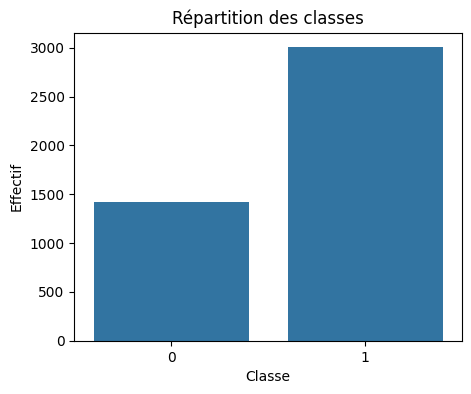

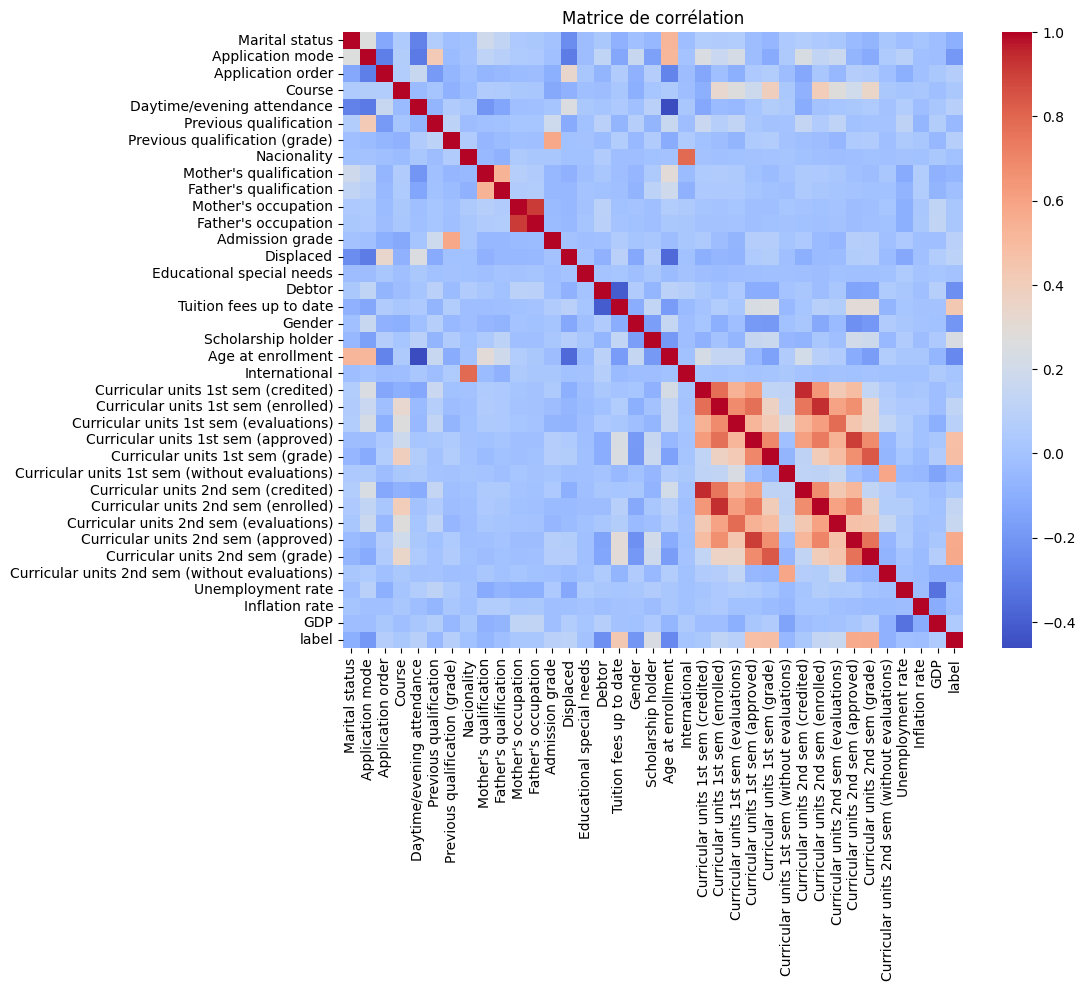

In [14]:
# Visualisation globale des classes + distributions par classe
target = "label"
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Nb features numériques:", len(num_cols))
print("Répartition classes:\n", df[target].value_counts())

# 1) Distribution globale des classes
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=target)
plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Effectif")
plt.show()

# 2) Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols + [target]].corr(), cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


On remarque plusieurs corrélations fortes :  

- mother's correlation et father's correlation
- réussite au premier semestre et réussite au second semestre